In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 100)

In [2]:
fault_df = pd.read_csv(
    "../data/synthetic_fault_dataset.csv"
)

fault_df["timestamp"] = pd.to_datetime(
    fault_df["timestamp"]
)

print("Shape:", fault_df.shape)

print("\nFault distribution:")
print(
    fault_df["fault_type"].value_counts()
)

Shape: (7200, 75)

Fault distribution:
fault_type
normal          1200
spike           1200
bias            1200
drift           1200
stuck_sensor    1200
missing         1200
Name: count, dtype: int64


In [3]:
required_columns = [
    "timestamp",
    "temp",
    "rhum",
    "wspd",
    "pres",
    "fault_type",
    "fault_sensor",
    "scenario_id"
]

missing = [
    c for c in required_columns
    if c not in fault_df.columns
]

assert len(missing) == 0, (
    f"Missing columns: {missing}"
)

print("VALIDATION PASSED")

VALIDATION PASSED


In [4]:
clean_df = pd.read_csv(
    "../data/anomaly_results.csv"
)

clean_df["timestamp"] = pd.to_datetime(
    clean_df["timestamp"]
)

sensor_columns = [
    "temp",
    "rhum",
    "wspd",
    "pres"
]

for col in sensor_columns:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    ).astype(float)

print(
    "Clean data shape:",
    clean_df.shape
)

Clean data shape: (8647, 72)


In [5]:
assert all(
    col in clean_df.columns
    for col in sensor_columns
)

print("VALIDATION PASSED")

VALIDATION PASSED


In [6]:
fault_df["actual_anomaly"] = (
    fault_df["fault_type"] != "normal"
).astype(int)

print(
    fault_df[
        [
            "fault_type",
            "actual_anomaly"
        ]
    ]
    .drop_duplicates()
    .sort_values("fault_type")
)

        fault_type  actual_anomaly
2400          bias               1
3600         drift               1
6000       missing               1
0           normal               0
1200         spike               1
4800  stuck_sensor               1


In [7]:
for fault_type in [
    "spike",
    "bias",
    "drift",
    "stuck_sensor",
    "missing"
]:
    
    assert (
        fault_df.loc[
            fault_df["fault_type"] == fault_type,
            "actual_anomaly"
        ] == 1
    ).all()

assert (
    fault_df.loc[
        fault_df["fault_type"] == "normal",
        "actual_anomaly"
    ] == 0
).all()

print(
    "VALIDATION PASSED: "
    "ground-truth labels are correct."
)

VALIDATION PASSED: ground-truth labels are correct.


In [8]:
fault_df["missing_anomaly"] = (
    fault_df[sensor_columns]
    .isna()
    .any(axis=1)
).astype(int)

In [9]:
missing_actual = (
    fault_df["fault_type"] == "missing"
)

print(
    pd.crosstab(
        fault_df["fault_type"],
        fault_df["missing_anomaly"]
    )
)

missing_anomaly     0     1
fault_type                 
bias             1200     0
drift            1200     0
missing             0  1200
normal           1200     0
spike            1200     0
stuck_sensor     1200     0


In [10]:
missing_rows = fault_df[
    fault_df["fault_type"] == "missing"
]

assert (
    missing_rows["missing_anomaly"] == 1
).all()

print(
    "VALIDATION PASSED: "
    "missing detector identifies injected missing values."
)

VALIDATION PASSED: missing detector identifies injected missing values.


In [11]:
def mad_parameters(series):
    
    series = series.dropna()
    
    median = series.median()
    
    mad = np.median(
        np.abs(series - median)
    )
    
    robust_std = 1.4826 * mad
    
    if robust_std == 0 or not np.isfinite(robust_std):
        robust_std = series.std()
    
    if robust_std == 0 or not np.isfinite(robust_std):
        robust_std = 1.0
    
    return median, robust_std

In [12]:
mad_params = {}

for sensor in sensor_columns:
    
    median, scale = mad_parameters(
        clean_df[sensor]
    )
    
    mad_params[sensor] = {
        "median": median,
        "scale": scale
    }

mad_params

{'temp': {'median': np.float64(26.8), 'scale': np.float64(2.5204199999999988)},
 'rhum': {'median': np.float64(79.0), 'scale': np.float64(16.3086)},
 'wspd': {'median': np.float64(14.0), 'scale': np.float64(9.636899999999999)},
 'pres': {'median': np.float64(1009.3),
  'scale': np.float64(3.558239999999966)}}

In [13]:
MAD_THRESHOLD = 3.5

for sensor in sensor_columns:
    
    median = mad_params[sensor]["median"]
    scale = mad_params[sensor]["scale"]
    
    deviation = (
        np.abs(
            fault_df[sensor] - median
        ) / scale
    )
    
    fault_df[
        f"{sensor}_mad_score"
    ] = deviation

In [14]:
mad_score_columns = [
    f"{sensor}_mad_score"
    for sensor in sensor_columns
]

fault_df["statistical_anomaly"] = (
    fault_df[mad_score_columns]
    .max(axis=1)
    >= MAD_THRESHOLD
).astype(int)

In [15]:
print(
    pd.crosstab(
        fault_df["fault_type"],
        fault_df["statistical_anomaly"]
    )
)

statistical_anomaly     0    1
fault_type                    
bias                 1038  162
drift                1070  130
missing              1200    0
normal               1195    5
spike                1123   77
stuck_sensor         1199    1


In [16]:
X_train = clean_df[
    sensor_columns
].copy()

X_train = X_train.dropna()

print(
    "Isolation Forest training rows:",
    len(X_train)
)

Isolation Forest training rows: 8647


In [17]:
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train)

print(
    "Isolation Forest trained successfully."
)

Isolation Forest trained successfully.


In [18]:
clean_medians = (
    clean_df[
        sensor_columns
    ]
    .median()
)

X_test_if = (
    fault_df[sensor_columns]
    .fillna(clean_medians)
)

In [19]:
if_raw_prediction = iso_model.predict(
    X_test_if
)

fault_df["if_anomaly"] = (
    if_raw_prediction == -1
).astype(int)

In [20]:
print(
    fault_df["if_anomaly"]
    .value_counts()
)

assert set(
    fault_df["if_anomaly"].unique()
).issubset({0, 1})

print(
    "VALIDATION PASSED"
)

if_anomaly
0    6795
1     405
Name: count, dtype: int64
VALIDATION PASSED


In [21]:
fault_df["combined_anomaly"] = (
    (
        fault_df["if_anomaly"] == 1
    )
    &
    (
        fault_df["statistical_anomaly"] == 1
    )
    |
    (
        fault_df["missing_anomaly"] == 1
    )
).astype(int)

In [22]:
detectors = [
    "if_anomaly",
    "statistical_anomaly",
    "missing_anomaly",
    "combined_anomaly"
]

for detector in detectors:
    
    assert set(
        fault_df[detector].unique()
    ).issubset({0, 1})

print(
    "VALIDATION PASSED: "
    "all detector outputs are binary."
)

VALIDATION PASSED: all detector outputs are binary.


In [23]:
def evaluate_detector(
    y_true,
    y_pred,
    detector_name
):
    
    return {
        "Detector": detector_name,
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

In [24]:
y_true = fault_df[
    "actual_anomaly"
]

results = []

for detector in detectors:
    
    results.append(
        evaluate_detector(
            y_true,
            fault_df[detector],
            detector
        )
    )

metrics_df = pd.DataFrame(
    results
)

metrics_df

,Detector,Precision,Recall,F1
0,if_anomaly,0.930864,0.062833,0.117721
1,statistical_anomaly,0.986667,0.061667,0.116078
2,missing_anomaly,1.000000,0.200000,0.333333
3,combined_anomaly,0.999271,0.228500,0.371948


In [25]:
cm = confusion_matrix(
    fault_df["actual_anomaly"],
    fault_df["combined_anomaly"]
)

print(cm)

[[1199    1]
 [4629 1371]]


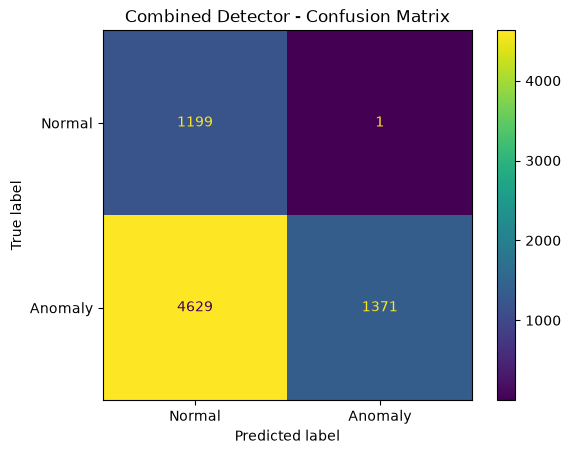

In [26]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Anomaly"
    ]
)

disp.plot()

plt.title(
    "Combined Detector - Confusion Matrix"
)

plt.show()

In [27]:
print(
    classification_report(
        fault_df["actual_anomaly"],
        fault_df["combined_anomaly"],
        target_names=[
            "Normal",
            "Anomaly"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.21      1.00      0.34      1200
     Anomaly       1.00      0.23      0.37      6000

    accuracy                           0.36      7200
   macro avg       0.60      0.61      0.36      7200
weighted avg       0.87      0.36      0.37      7200



In [28]:
fault_types_to_evaluate = [
    "spike",
    "bias",
    "drift",
    "stuck_sensor",
    "missing"
]

In [29]:
per_fault_results = []

for fault_type in fault_types_to_evaluate:
    
    subset = fault_df[
        fault_df["fault_type"] == fault_type
    ]
    
    detected = (
        subset["combined_anomaly"] == 1
    ).sum()
    
    total = len(subset)
    
    detection_rate = (
        detected / total
        if total > 0
        else 0
    )
    
    per_fault_results.append({
        "Fault Type": fault_type,
        "Total Fault Rows": total,
        "Detected Rows": detected,
        "Detection Rate": detection_rate
    })

per_fault_df = pd.DataFrame(
    per_fault_results
)

per_fault_df

,Fault Type,Total Fault Rows,Detected Rows,Detection Rate
0,spike,1200,39,0.032500
1,bias,1200,85,0.070833
2,drift,1200,47,0.039167
3,stuck_sensor,1200,0,0.000000
4,missing,1200,1200,1.000000


In [30]:
fault_metrics = []

for fault_type in fault_types_to_evaluate:
    
    y_true_fault = (
        fault_df["fault_type"]
        == fault_type
    ).astype(int)
    
    y_pred = fault_df[
        "combined_anomaly"
    ]
    
    fault_metrics.append({
        "Fault Type": fault_type,
        
        "Precision": precision_score(
            y_true_fault,
            y_pred,
            zero_division=0
        ),
        
        "Recall": recall_score(
            y_true_fault,
            y_pred,
            zero_division=0
        ),
        
        "F1": f1_score(
            y_true_fault,
            y_pred,
            zero_division=0
        )
    })

fault_metrics_df = pd.DataFrame(
    fault_metrics
)

fault_metrics_df

,Fault Type,Precision,Recall,F1
0,spike,0.028426,0.032500,0.030327
1,bias,0.061953,0.070833,0.066096
2,drift,0.034257,0.039167,0.036547
3,stuck_sensor,0.000000,0.000000,0.000000
4,missing,0.874636,1.000000,0.933126


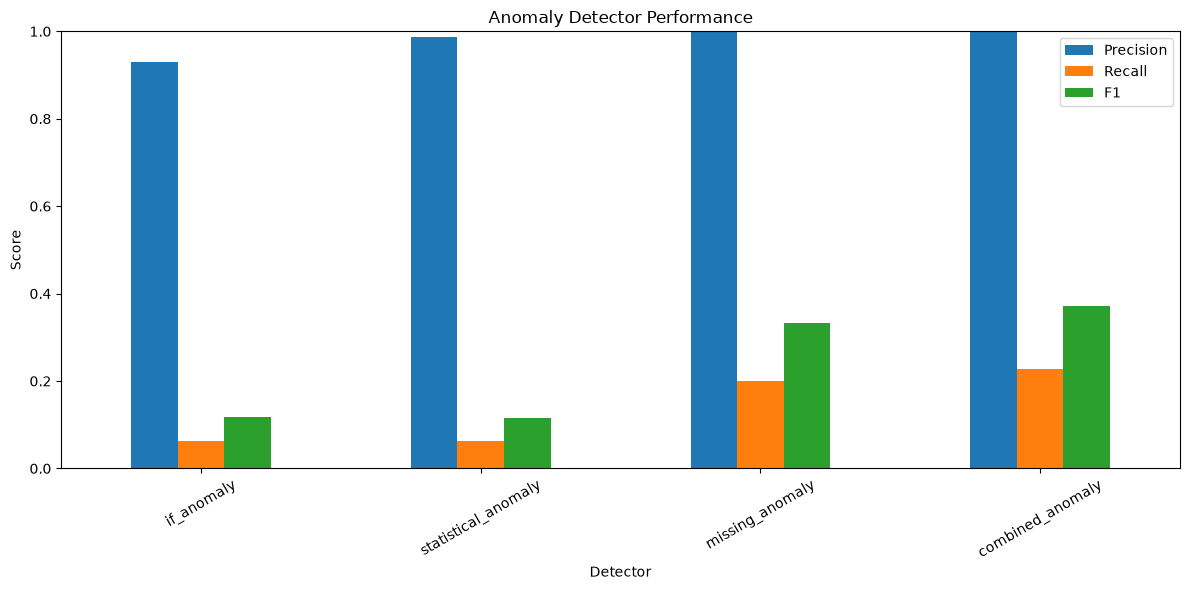

In [31]:
metrics_plot = metrics_df.set_index(
    "Detector"
)

metrics_plot[
    ["Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Anomaly Detector Performance"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [32]:
metrics_df.to_csv(
    "../data/detector_metrics.csv",
    index=False
)

per_fault_df.to_csv(
    "../data/per_fault_detection.csv",
    index=False
)

fault_metrics_df.to_csv(
    "../data/per_fault_metrics.csv",
    index=False
)

fault_df.to_csv(
    "../data/fault_detection_results.csv",
    index=False
)

print("All evaluation files saved.")

All evaluation files saved.


In [33]:
assert len(metrics_df) == 4

assert set(metrics_df["Detector"]) == {
    "if_anomaly",
    "statistical_anomaly",
    "missing_anomaly",
    "combined_anomaly"
}

assert len(per_fault_df) == 5

assert len(fault_metrics_df) == 5

assert fault_df["actual_anomaly"].isin(
    [0, 1]
).all()

assert fault_df["combined_anomaly"].isin(
    [0, 1]
).all()

print(
    "================================"
)
print(
    "ALL FINAL VALIDATIONS PASSED"
)
print(
    "================================"
)

ALL FINAL VALIDATIONS PASSED
